In [ ]:
import os
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d athina123/ph2dataset


Dataset URL: https://www.kaggle.com/datasets/athina123/ph2dataset
License(s): unknown
 96% 387M/405M [00:06<00:00, 55.2MB/s]
100% 405M/405M [00:06<00:00, 65.9MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("ph2dataset.zip","r") as z:
    z.extractall("skin_disease_segmented_dataset")


In [ ]:
import os

base_path = "/content/skin_disease_segmented_dataset/ph2_dataset"

img_dir = os.path.join(base_path, "trainx")
mask_dir = os.path.join(base_path, "trainy")

print("Total images:", len(os.listdir(img_dir)))
print("Total masks:", len(os.listdir(mask_dir)))


Total images: 200
Total masks: 200


In [ ]:
import os, glob, shutil
from sklearn.model_selection import train_test_split


# Collect all image file names (only .bmp)
all_imgs = [f for f in os.listdir(img_dir) if f.endswith(".bmp")]

print("Found images:", len(all_imgs))
print("Sample:", all_imgs[:5])

# Train/val split
train_imgs, val_imgs = train_test_split(all_imgs, test_size=0.2, random_state=42)

# Create output folders
os.makedirs("ph2_data/images/train", exist_ok=True)
os.makedirs("ph2_data/images/val", exist_ok=True)
os.makedirs("ph2_data/masks/train", exist_ok=True)
os.makedirs("ph2_data/masks/val", exist_ok=True)

# Copy function
def copy_data(img_list, split):
    for img in img_list:
        # copy image
        shutil.copy(os.path.join(img_dir, img), f"ph2_data/images/{split}")
        # copy mask (replace suffix correctly)
        mask_name = img.replace(".bmp", "_lesion.bmp")
        shutil.copy(os.path.join(mask_dir, mask_name), f"ph2_data/masks/{split}")

# Copy data
copy_data(train_imgs, "train")
copy_data(val_imgs, "val")

print("Train/Val split completed ✅")


Found images: 200
Sample: ['IMD176.bmp', 'IMD132.bmp', 'IMD430.bmp', 'IMD171.bmp', 'IMD256.bmp']
Train/Val split completed ✅


In [ ]:
import os

# Check if the file exists in the copied folder
print(os.path.exists("ph2_data/masks/train/IMD150_lesion.bmp"))


False


In [ ]:
!pip install segmentation-models-pytorch --quiet
!pip install albumentations --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:00


In [ ]:
class SkinDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # keep only images with masks
        self.img_names = []
        for img_name in os.listdir(img_dir):
            mask_name = img_name.replace(".bmp", "_lesion.bmp")
            if os.path.exists(os.path.join(mask_dir, mask_name)):
                self.img_names.append(img_name)
            else:
                print(f"Skipping {img_name}, mask not found")

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        mask_name = img_name.replace(".bmp", "_lesion.bmp")
        mask_path = os.path.join(self.mask_dir, mask_name)

        # Load image and mask
        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L")).astype(np.float32) / 255.0  # normalize to 0-1

        # Apply augmentations if any
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float()

        return image, mask


In [ ]:
import numpy as np

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2(),
])


In [ ]:
from torch.utils.data import DataLoader

train_dataset = SkinDataset("ph2_data/images/train", "ph2_data/masks/train", transform=train_transform)
val_dataset   = SkinDataset("ph2_data/images/val", "ph2_data/masks/val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


⚠️ Skipping IMD150.bmp, mask not found
Train batches: 40
Val batches: 10


In [ ]:
import torch

# Use GPU if available, else fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
import segmentation_models_pytorch as smp

# U-Net with ResNet34 encoder pretrained on ImageNet
model = smp.Unet(
    encoder_name="resnet34",        # encoder (backbone)
    encoder_weights="imagenet",     # use ImageNet pretrained weights
    in_channels=3,                  # input RGB
    classes=1,                      # binary segmentation (lesion vs background)
).to(device)


In [ ]:
import torch.nn as nn
import torch.optim as optim

loss_fn = smp.losses.DiceLoss(mode="binary")  # Dice loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss = loss_fn(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/10, Train Loss: 0.1304
Epoch 2/10, Train Loss: 0.1175
Epoch 3/10, Train Loss: 0.1232
Epoch 4/10, Train Loss: 0.1102
Epoch 5/10, Train Loss: 0.1123
Epoch 6/10, Train Loss: 0.0981
Epoch 7/10, Train Loss: 0.0978
Epoch 8/10, Train Loss: 0.1142
Epoch 9/10, Train Loss: 0.1286
Epoch 10/10, Train Loss: 0.0999


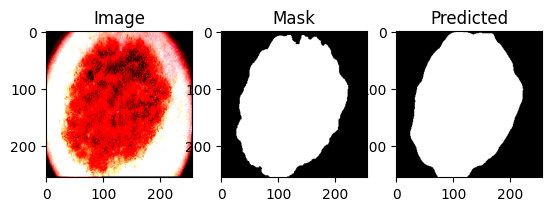

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        preds = torch.sigmoid(preds) > 0.5  # threshold

        # show first sample
        img = imgs[2].cpu().permute(1,2,0).numpy()
        mask = masks[2].cpu().squeeze().numpy()
        pred = preds[2].cpu().squeeze().numpy()

        plt.subplot(1,3,1); plt.imshow(img); plt.title("Image")
        plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask")
        plt.subplot(1,3,3); plt.imshow(pred, cmap="gray"); plt.title("Predicted")
        plt.show()
        break


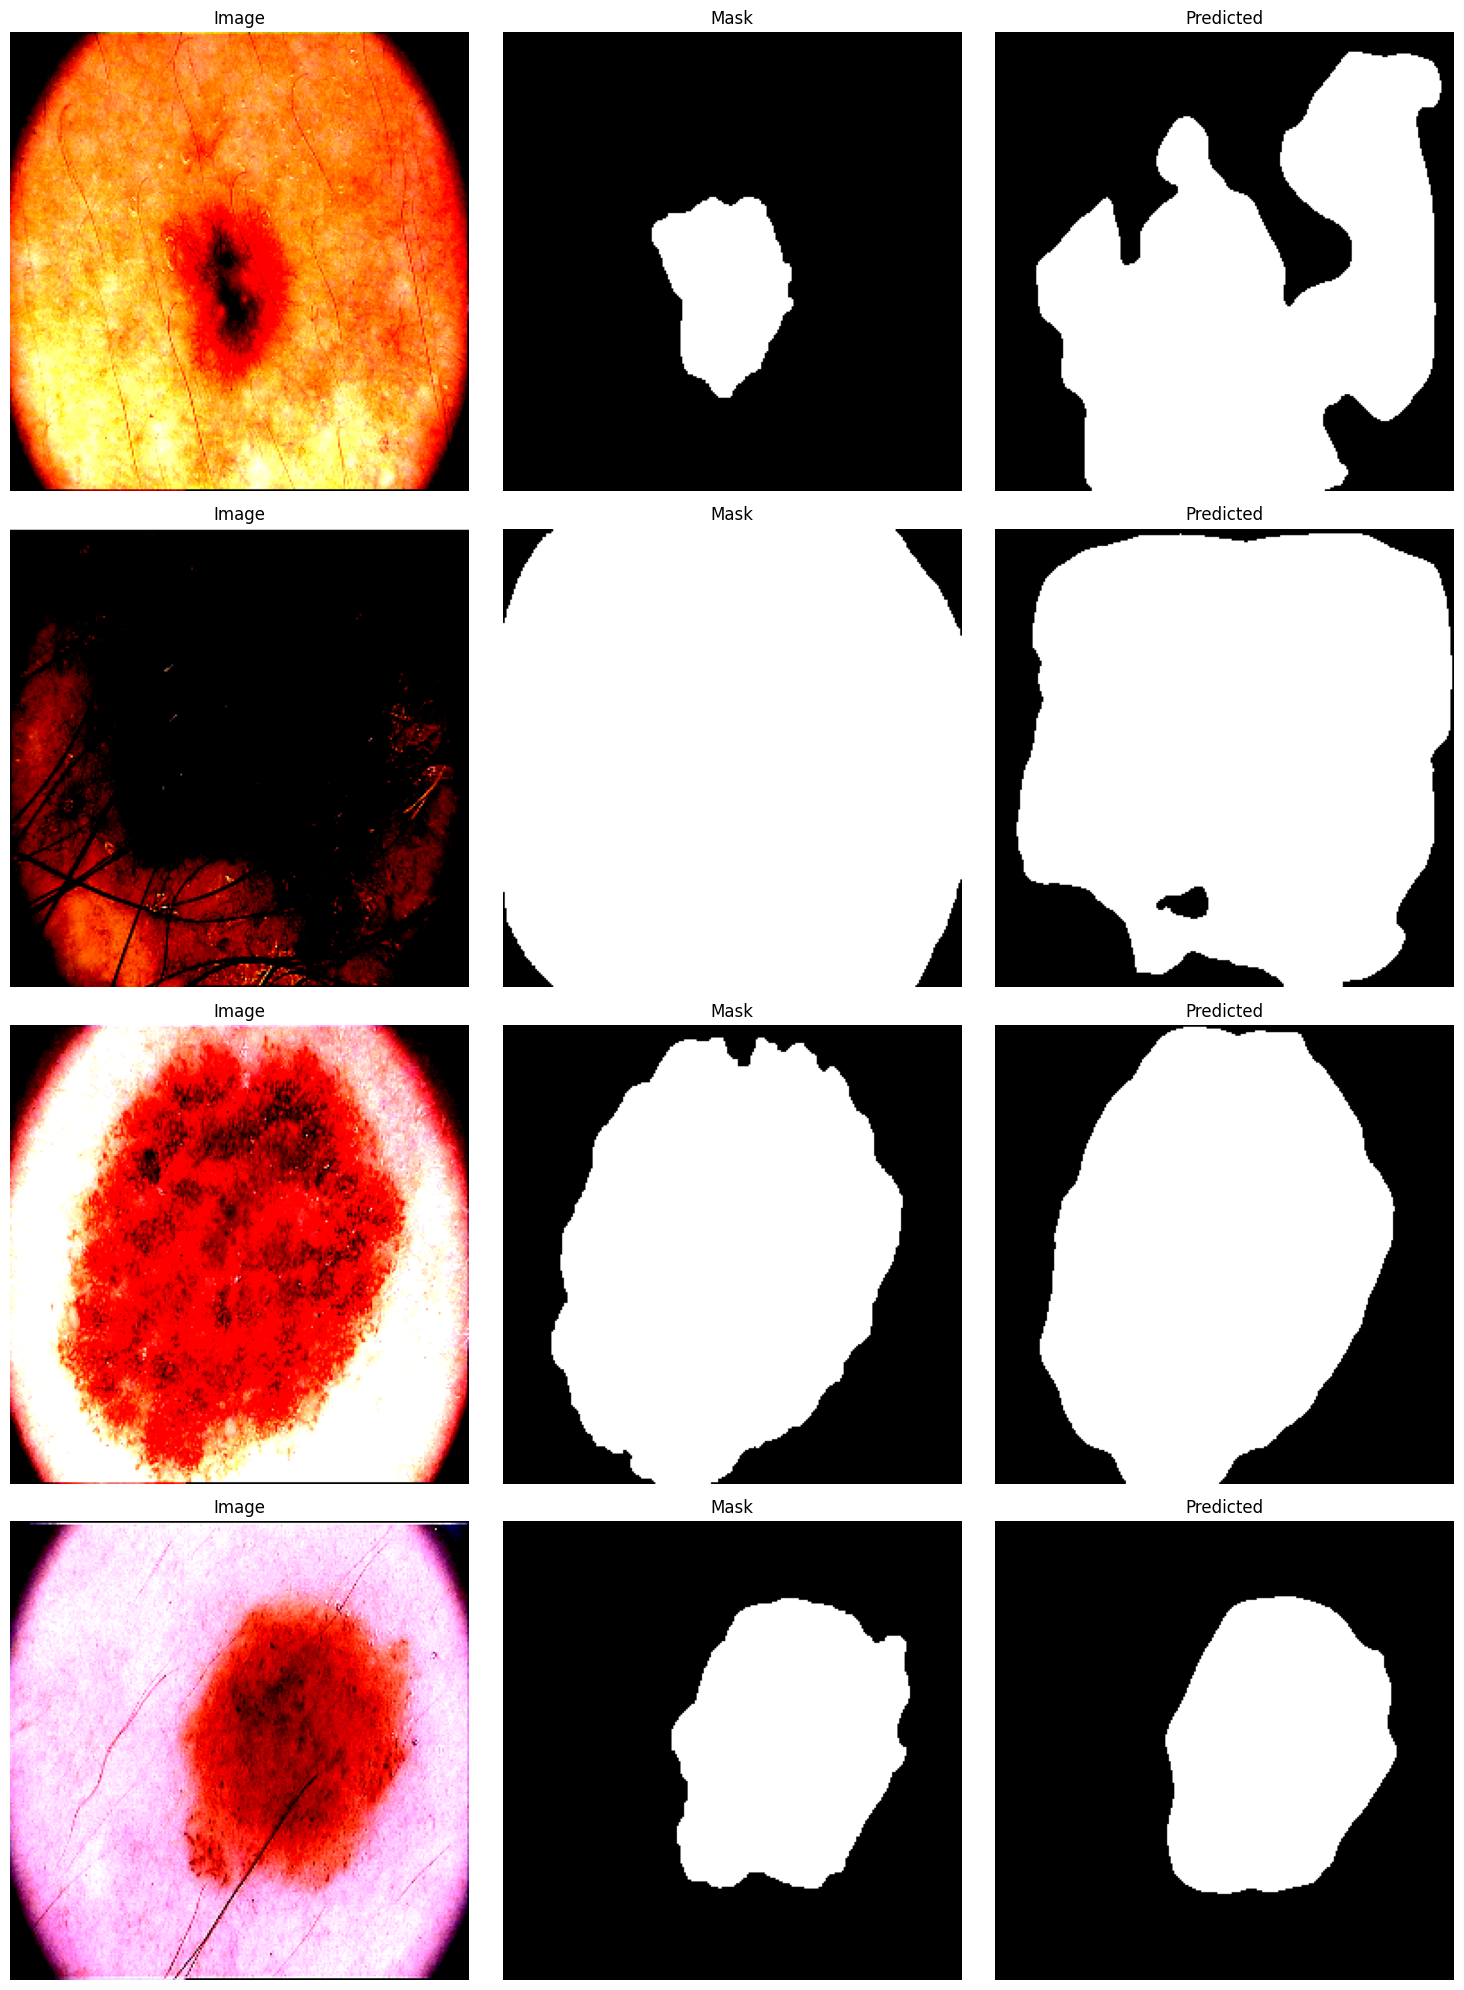

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()
with torch.no_grad():
    count = 0
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        preds = torch.sigmoid(preds) > 0.5  # threshold

        batch_size = imgs.shape[0]
        # Display up to 5 images from this batch
        n_show = min(5, batch_size)

        plt.figure(figsize=(15, 5*n_show))  # adjust figure size
        for i in range(n_show):
            img = imgs[i].cpu().permute(1,2,0).numpy()
            mask = masks[i].cpu().squeeze().numpy()
            pred = preds[i].cpu().squeeze().numpy()

            # Original image
            plt.subplot(n_show, 3, i*3 + 1)
            plt.imshow(img)
            plt.title("Image")
            plt.axis('off')

            # Ground truth mask
            plt.subplot(n_show, 3, i*3 + 2)
            plt.imshow(mask, cmap="gray")
            plt.title("Mask")
            plt.axis('off')

            # Predicted mask
            plt.subplot(n_show, 3, i*3 + 3)
            plt.imshow(pred, cmap="gray")
            plt.title("Predicted")
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        break  # remove this if you want to visualize multiple batches


In [ ]:
import torch

def dice_coef(preds, masks, smooth=1e-6):
    """Compute Dice coefficient for a batch"""
    preds = preds.float()
    masks = masks.float()
    intersection = (preds * masks).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3))
    dice = (2 * intersection + smooth) / (union + smooth)
    return dice

# Make sure model is in eval mode
model.eval()
dice_scores = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        preds = torch.sigmoid(preds) > 0.5  # threshold to 0/1

        dice = dice_coef(preds, masks)
        dice_scores.append(dice.cpu())

# Compute average Dice over all batches
all_dice = torch.cat(dice_scores)
val_dice = all_dice.mean().item()

print(f"Validation Dice (Accuracy): {val_dice:.4f}")


Validation Dice (Accuracy): 0.8790


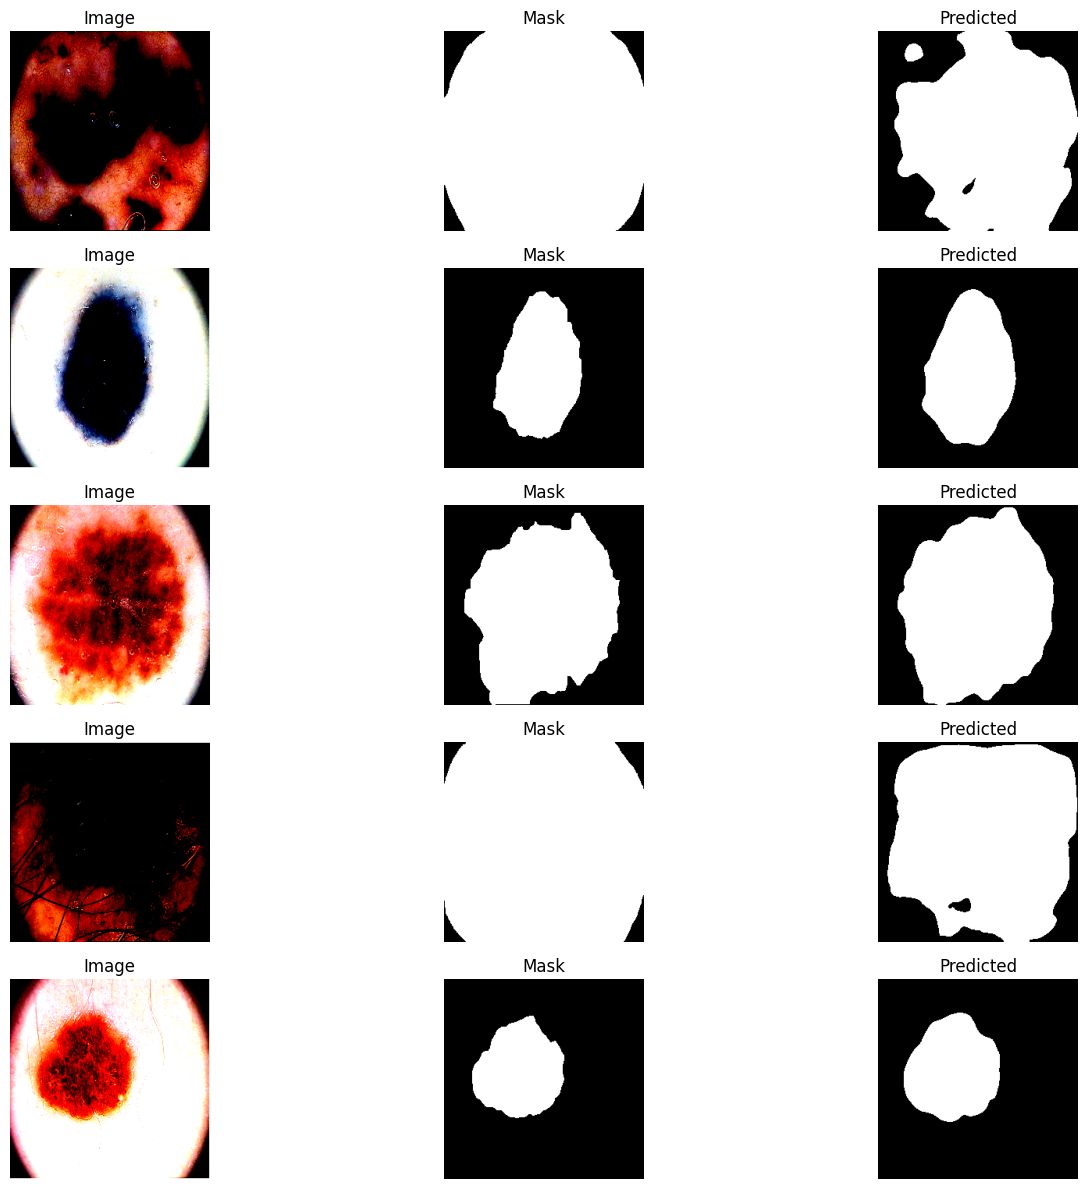

In [ ]:
import matplotlib.pyplot as plt
import torch
import random

model.eval()
with torch.no_grad():
    # Get all images from val_loader into a list (or sample from batches)
    val_imgs_list = []
    val_masks_list = []
    for imgs, masks in val_loader:
        val_imgs_list.append(imgs)
        val_masks_list.append(masks)

    # Concatenate batches
    val_imgs_all = torch.cat(val_imgs_list, dim=0)
    val_masks_all = torch.cat(val_masks_list, dim=0)

    # Randomly pick 5 indices
    indices = random.sample(range(len(val_imgs_all)), 5)

    plt.figure(figsize=(15, 12))
    for i, idx in enumerate(indices):
        img = val_imgs_all[idx].to(device).unsqueeze(0)
        mask = val_masks_all[idx].to(device).unsqueeze(0)

        pred = model(img)
        pred = torch.sigmoid(pred) > 0.5

        img = img[0].cpu().permute(1,2,0).numpy()
        mask = mask[0].cpu().squeeze().numpy()
        pred = pred[0].cpu().squeeze().numpy()

        # Original image
        plt.subplot(5,3,i*3 + 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis('off')

        # Ground truth mask
        plt.subplot(5,3,i*3 + 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Mask")
        plt.axis('off')

        # Predicted mask
        plt.subplot(5,3,i*3 + 3)
        plt.imshow(pred, cmap="gray")
        plt.title("Predicted")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
